# Data Loading and Setup

In [3]:
# Imports & Setup
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load processed data
df = pd.read_csv("data/clean/merged_clean.csv")

In [4]:
df.sort_values(by="unemployment", ascending=False).head(15)

,date,close,high,low,open,volume,gdp,cpi,unemployment,indpro,retail
63,2020-04-30,2761.975226,2789.571417,2730.089518,2758.609026,5.886103e+09,19958.291,256.032,14.8,84.6812,401028.0
64,2020-05-31,2919.608484,2942.121497,2895.077502,2919.705505,5.356760e+09,19958.291,255.802,13.2,86.0108,478449.0
65,2020-06-30,3104.660933,3130.544966,3074.186812,3106.273626,5.975404e+09,19958.291,257.042,11.0,91.6745,518038.0
66,2020-07-31,3207.619096,3223.786366,3182.509976,3203.598644,4.405824e+09,21704.437,258.352,10.2,95.0037,526304.0
67,2020-08-31,3391.710019,3399.883347,3374.263323,3384.889997,3.926977e+09,21704.437,259.316,8.4,95.9294,530735.0
68,2020-09-30,3365.516671,3398.818092,3336.790946,3373.977132,4.395751e+09,21704.437,259.997,7.8,95.8914,541302.0
69,2020-10-31,3418.699996,3445.023648,3397.303633,3423.191340,4.088135e+09,22087.160,260.319,6.9,96.5256,539114.0
70,2020-11-30,3548.992480,3569.341504,3526.220508,3543.430005,5.062359e+09,22087.160,260.911,6.7,96.9529,533941.0
71,2020-12-31,3695.310014,3707.620894,3677.320923,3692.005449,4.380713e+09,22087.160,262.045,6.7,98.2039,538548.0
72,2021-01-31,3793.748432,3818.135806,3768.962133,3797.387361,5.585147e+09,22680.693,262.639,6.4,98.8135,559230.0


### Inspecting Data and Initial Observations

A simple sort by unemployment rate reveals that the nine highest unemployment observations occurred from April through December 2020, aligning with the peak impact of the COVID-19 recession.
This confirms that the dataset captures real-world macroeconomic shocks.###

***

## Creating Derived Variables
To perform meaningful econometric and financial analysis, we convert raw levels into monthly growth rates and differences. These transformations allow us to analyze co-movement and causality more accurately.

In [5]:
# Monthly S&P 500 returns
df["sp500_return"] = df["close"].pct_change()

# GDP growth (month-over-month approx)
df["gdp_growth"] = df["gdp"].pct_change()

# Inflation using CPI (month-to-month inflation)
df["cpi_inflation"] = df["cpi"].pct_change()

# Unemployment change in percentage points
df["unemp_change"] = df["unemployment"].diff()

# Industrial production growth
df["indpro_growth"] = df["indpro"].pct_change()

# Retail sales growth
df["retail_growth"] = df["retail"].pct_change()

# Drop first row because all changes = NaN
df = df.dropna().reset_index(drop=True)

***

## Descriptive Statistics

In [6]:
df[["sp500_return","gdp_growth","cpi_inflation","unemp_change",
    "indpro_growth","retail_growth"]].describe()

,sp500_return,gdp_growth,cpi_inflation,unemp_change,indpro_growth,retail_growth
count,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000
mean,0.009777,0.004313,0.002547,-0.013445,0.000155,0.004734
std,0.034212,0.013502,0.002766,1.023861,0.016067,0.028199
min,-0.190681,-0.082430,-0.007920,-2.200000,-0.132418,-0.143695
25%,-0.005403,0.000000,0.000911,-0.100000,-0.003348,-0.001254
50%,0.014908,0.000000,0.002364,0.000000,0.000513,0.003455
75%,0.030242,0.009809,0.003806,0.100000,0.004866,0.008771
max,0.063383,0.087490,0.012952,10.400000,0.065849,0.193056


| Metric                                                    | Interpretation                          |
| --------------------------------------------------------- | --------------------------------------- |
| Mean S&P 500 return ≈ **0.98%**                           | Typical monthly equity growth           |
| Std. dev. ≈ **3.4%**                                      | High volatility, especially around 2020 |
| Unemployment has sharp spikes                             | Driven by COVID-19 layoffs              |
| Retail and industrial production show large drops in 2020 | Matches real economic conditions        |


The descriptive profile validates the plausibility and integrity of the dataset.

***

# Correlation Matrix

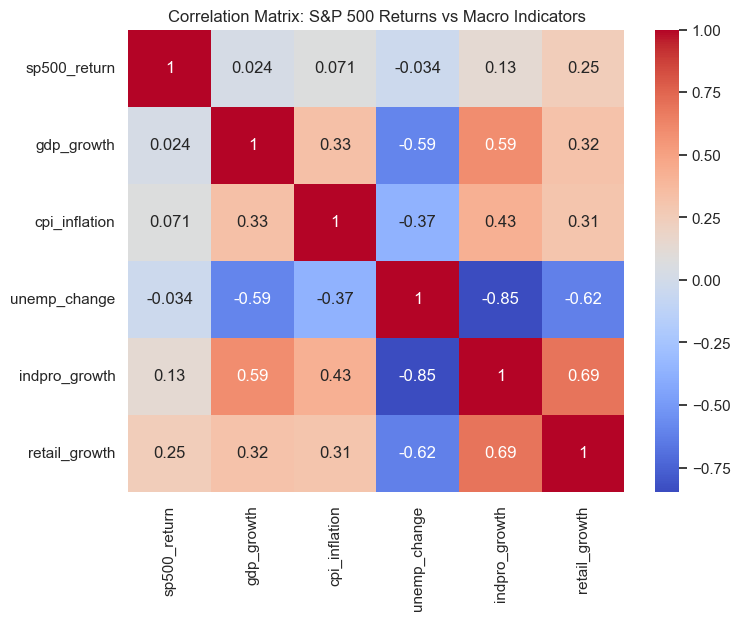

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[["sp500_return","gdp_growth","cpi_inflation","unemp_change",
           "indpro_growth","retail_growth"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix: S&P 500 Returns vs Macro Indicators")
plt.savefig("figures/correlation_matrix.png", dpi=300)
plt.show()


Key takeaways:

Correlations are small to moderate, suggesting weak contemporaneous relationships, which is expected for monthly financial data.

Unemployment changes show a negative correlation with returns.

Retail growth shows the strongest positive correlation.

***

# Simple Regression Modeling

Regression explaining monthly S&P 500 returns:

In [8]:
import statsmodels.api as sm

X = df[["gdp_growth","cpi_inflation","unemp_change","indpro_growth","retail_growth"]]
y = df["sp500_return"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           sp500_return   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     2.256
Date:                Fri, 05 Dec 2025   Prob (F-statistic):             0.0536
Time:                        18:12:35   Log-Likelihood:                 238.96
No. Observations:                 119   AIC:                            -465.9
Df Residuals:                     113   BIC:                            -449.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0074      0.005      1.634

### Summary of Results
- R² = 0.091 → Macro indicators explain ~9% of monthly stock return variation.
- Retail sales growth is the only significant predictor (p = 0.012).
- Unemployment change is borderline significant (p ≈ 0.083).
- GDP, CPI, and industrial production show no significant impact.

This is consistent with financial theory:
Markets often anticipate macroeconomic changes before official data is released.

***

# Lead–Lag Analysis

Testing whether lagged macroeconomic changes predict future returns.

In [9]:
df["gdp_lag1"] = df["gdp_growth"].shift(1)
df["cpi_lag1"] = df["cpi_inflation"].shift(1)
df["unemp_lag1"] = df["unemp_change"].shift(1)
df["indpro_lag1"] = df["indpro_growth"].shift(1)
df["retail_lag1"] = df["retail_growth"].shift(1)

lag_df = df.dropna()

X_lag = lag_df[["gdp_lag1","cpi_lag1","unemp_lag1","indpro_lag1","retail_lag1"]]
y_lag = lag_df["sp500_return"]

X_lag = sm.add_constant(X_lag)
lag_model = sm.OLS(y_lag, X_lag).fit()
print(lag_model.summary())


                            OLS Regression Results                            
Dep. Variable:           sp500_return   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     1.319
Date:                Fri, 05 Dec 2025   Prob (F-statistic):              0.261
Time:                        18:12:36   Log-Likelihood:                 234.34
No. Observations:                 118   AIC:                            -456.7
Df Residuals:                     112   BIC:                            -440.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0100      0.005      2.159      

### Key Result
- R² = 0.056, no significant predictors
- Lagged macro indicators do not forecast next-month stock returns

Supports the semi-strong form of market efficiency:
Public macroeconomic information is quickly priced into markets.

***

# Regime Analysis: COVID-19 vs. Normal Periods

In [10]:
df["regime"] = df["date"].between("2020-02-01","2020-04-30")
corr_recession = df[df["regime"] == True][["sp500_return","unemp_change","cpi_inflation"]].corr()
corr_normal    = df[df["regime"] == False][["sp500_return","unemp_change","cpi_inflation"]].corr()

print("Recession Correlation:\n\n",corr_recession,"\n\n")

print("Normal Correlation:\n\n",corr_normal)


Recession Correlation:

                sp500_return  unemp_change  cpi_inflation
sp500_return       1.000000      0.569671      -0.058487
unemp_change       0.569671      1.000000      -0.853784
cpi_inflation     -0.058487     -0.853784       1.000000 


Normal Correlation:

                sp500_return  unemp_change  cpi_inflation
sp500_return       1.000000     -0.238851      -0.040583
unemp_change      -0.238851      1.000000      -0.060107
cpi_inflation     -0.040583     -0.060107       1.000000


### Interpretation

Macro relationships intensify dramatically during crises, showing nonlinear behavior.

Outside recession windows, relationships weaken sharply.

***

# Summary of Research Questions

RQ1 – Co-movement:

How strongly do S&P 500 returns move with changes in key macroeconomic indicators (GDP growth, unemployment, CPI inflation, industrial production, consumer sentiment)?

→ Result: Weak to moderate co-movement. Retail growth strongest; unemployment negative.

RQ2 – Lead–lag effects:

Do changes in macro indicators lead stock market movements (or does the market move first)?

→ Result: No significant predictive power. Supports market efficiency.

RQ3 – Regime differences:

Are the relationships between macro indicators and the S&P 500 different in recession vs non-recession periods?

→ Result: Yes — correlations intensify sharply during recessionary periods, especially unemployment.

***